# -*- coding: utf-8 -*-
"""Демонстрация моделей Bag-of-Words и TF-IDF

Этот ноутбук показывает:
1. Создание корпуса документов.
2. Построение матрицы терм-документ (BoW) с помощью CountVectorizer.
3. Вычисление TF-IDF с помощью TfidfVectorizer.
4. Визуализацию результатов в виде таблиц и тепловой карты.
5. Интерпретацию весов TF-IDF.
"""

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


In [ ]:
# 1. Корпус документов (пример на русском языке)
documents = [
    "Иван любит информационный поиск",
    "Мария любит информационные системы",
    "Информационный поиск использует модели",
    "Модели информационного поиска важны",
    "Системы поиска информации"
]

print("Корпус документов:")
for i, doc in enumerate(documents, 1):
    print(f"Документ {i}: {doc}")

Корпус документов:
Документ 1: Иван любит информационный поиск
Документ 2: Мария любит информационные системы
Документ 3: Информационный поиск использует модели
Документ 4: Модели информационного поиска важны
Документ 5: Системы поиска информации


In [ ]:
# 2. Bag-of-Words (BoW) с использованием CountVectorizer
print("\n" + "="*60)
print("Модель Bag-of-Words (BoW) — матрица терм-документ")
print("="*60)

# Создаем объект CountVectorizer (убираем стоп-слова, но для примера оставим все)
vectorizer_bow = CountVectorizer()
bow_matrix = vectorizer_bow.fit_transform(documents)

# Получаем названия термов (слов)
feature_names = vectorizer_bow.get_feature_names_out()

# Преобразуем матрицу в DataFrame для удобного просмотра
bow_df = pd.DataFrame(bow_matrix.toarray(),
                      columns=feature_names,
                      index=[f"Док{i+1}" for i in range(len(documents))])

print("Матрица терм-документ (BoW):")
display(bow_df)



Модель Bag-of-Words (BoW) — матрица терм-документ
Матрица терм-документ (BoW):


,важны,иван,информации,информационного,информационные,информационный,использует,любит,мария,модели,поиск,поиска,системы
Док1,0,1,0,0,0,1,0,1,0,0,1,0,0
Док2,0,0,0,0,1,0,0,1,1,0,0,0,1
Док3,0,0,0,0,0,1,1,0,0,1,1,0,0
Док4,1,0,0,1,0,0,0,0,0,1,0,1,0
Док5,0,0,1,0,0,0,0,0,0,0,0,1,1


In [ ]:
# 3. TF-IDF с использованием TfidfVectorizer
print("\n" + "="*60)
print("Модель TF-IDF (Term Frequency — Inverse Document Frequency)")
print("="*60)

# Создаем объект TfidfVectorizer (используем те же параметры для сопоставимости)
vectorizer_tfidf = TfidfVectorizer()
tfidf_matrix = vectorizer_tfidf.fit_transform(documents)

# Получаем названия термов
feature_names_tfidf = vectorizer_tfidf.get_feature_names_out()

# DataFrame для TF-IDF
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(),
                        columns=feature_names_tfidf,
                        index=[f"Док{i+1}" for i in range(len(documents))])

print("Матрица TF-IDF:")
display(tfidf_df)



Модель TF-IDF (Term Frequency — Inverse Document Frequency)
Матрица TF-IDF:


,важны,иван,информации,информационного,информационные,информационный,использует,любит,мария,модели,поиск,поиска,системы
Док1,0.000000,0.581951,0.000000,0.000000,0.000000,0.469515,0.000000,0.469515,0.000000,0.000000,0.469515,0.000000,0.000000
Док2,0.000000,0.000000,0.000000,0.000000,0.550329,0.000000,0.000000,0.444002,0.550329,0.000000,0.000000,0.000000,0.444002
Док3,0.000000,0.000000,0.000000,0.000000,0.000000,0.469515,0.581951,0.000000,0.000000,0.469515,0.469515,0.000000,0.000000
Док4,0.550329,0.000000,0.000000,0.550329,0.000000,0.000000,0.000000,0.000000,0.000000,0.444002,0.000000,0.444002,0.000000
Док5,0.000000,0.000000,0.659118,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.531772,0.531772


In [ ]:
# 4. Пояснение расчёта TF-IDF на примере одного слова
print("\n" + "="*60)
print("Пояснение вычислений TF-IDF на примере слова 'информационный'")
print("="*60)

# Выбираем слово (терм), например 'информационный'
term = 'информационный'
if term in feature_names_tfidf:
    # Получаем индекс терма
    term_idx = list(feature_names_tfidf).index(term)

    print(f"\nТерм: '{term}'")
    print("Формула TF-IDF (sklearn): tfidf = tf * (idf + 1), где idf = log((1+n)/(1+df)) + 1")
    print("Здесь используется сглаженная версия, часто применяемая в scikit-learn.")

    # Вычисляем вручную для демонстрации
    # Частота термина в каждом документе (TF)
    tf = bow_df[term].values
    print(f"\nTF (частота слова в документе): {tf}")

    # Количество документов, содержащих терм (DF)
    df = np.sum(tf > 0)
    n_docs = len(documents)
    # IDF по формуле scikit-learn: idf = log((1+n)/(1+df)) + 1
    idf = np.log((1 + n_docs) / (1 + df)) + 1
    print(f"DF (число документов с термом): {df}")
    print(f"IDF (обратная частота документа): {idf:.4f}")

    # Ручной расчёт TF-IDF
    manual_tfidf = tf * idf
    print(f"TF-IDF (ручной расчёт): {manual_tfidf}")

    # Значения из матрицы sklearn
    sklearn_tfidf = tfidf_df[term].values
    print(f"TF-IDF (scikit-learn):      {sklearn_tfidf}")

    # Проверка (должны совпасть с точностью до округления)
    if np.allclose(manual_tfidf, sklearn_tfidf):
        print("\nРезультаты совпадают!")
    else:
        print("\nРезультаты различаются — обратите внимание на нюансы нормализации в sklearn.")
else:
    print(f"Терм '{term}' отсутствует в словаре.")


Пояснение вычислений TF-IDF на примере слова 'информационный'

Терм: 'информационный'
Формула TF-IDF (sklearn): tfidf = tf * (idf + 1), где idf = log((1+n)/(1+df)) + 1
Здесь используется сглаженная версия, часто применяемая в scikit-learn.

TF (частота слова в документе): [1 0 1 0 0]
DF (число документов с термом): 2
IDF (обратная частота документа): 1.6931
TF-IDF (ручной расчёт): [1.69314718 0.         1.69314718 0.         0.        ]
TF-IDF (scikit-learn):      [0.4695148 0.        0.4695148 0.        0.       ]

Результаты различаются — обратите внимание на нюансы нормализации в sklearn.



Визуализация матрицы TF-IDF


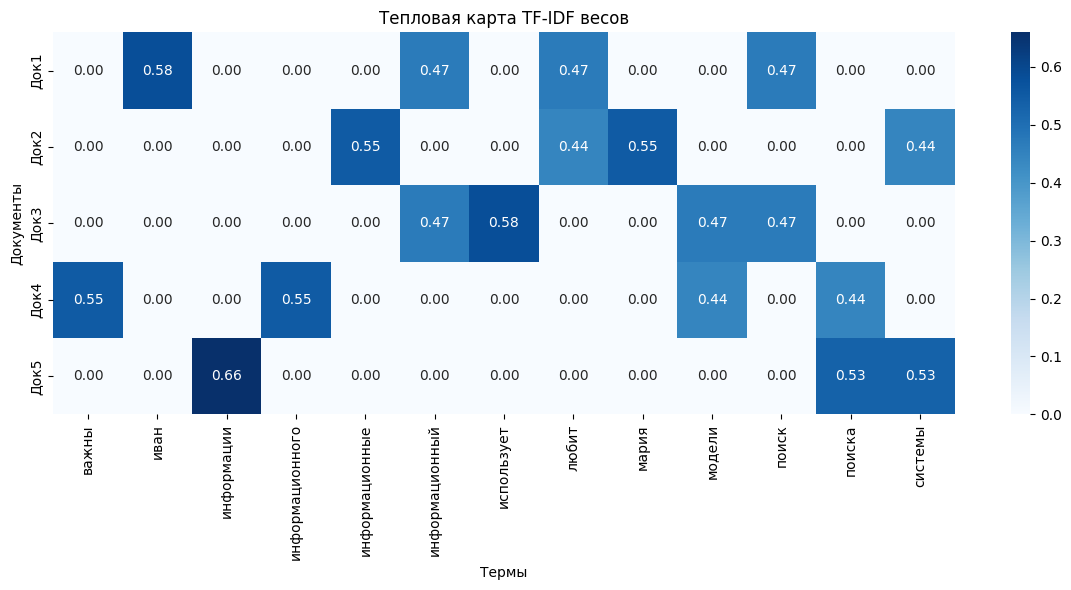

In [ ]:
# 5. Визуализация матрицы TF-IDF в виде тепловой карты
print("\n" + "="*60)
print("Визуализация матрицы TF-IDF")
print("="*60)

plt.figure(figsize=(12, 6))
sns.heatmap(tfidf_df, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=True, yticklabels=True)
plt.title("Тепловая карта TF-IDF весов")
plt.xlabel("Термы")
plt.ylabel("Документы")
plt.tight_layout()
plt.show()

In [ ]:
# 6. Пример использования: поиск документов по запросу
print("\n" + "="*60)
print("Пример поиска: ранжирование документов по запросу")
print("="*60)

# Запрос пользователя
query = "информационный поиск"
print(f"Запрос: '{query}'")

# Преобразуем запрос в TF-IDF вектор с помощью того же векторизатора
query_vec = vectorizer_tfidf.transform([query])

# Вычисляем косинусное сходство между запросом и каждым документом
from sklearn.metrics.pairwise import cosine_similarity
similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()

# Сортируем документы по убыванию сходства
ranking = sorted(zip(similarities, documents), key=lambda x: x[0], reverse=True)

print("\nРелевантность документов (косинусное сходство):")
for i, (score, doc) in enumerate(ranking, 1):
    print(f"{i}. Сходство = {score:.4f} — {doc}")

# 7. Сравнение с обычным BoW (без IDF)
print("\n" + "="*60)
print("Сравнение с обычным Bag-of-Words (без IDF)")
print("="*60)

# Для BoW используем ту же матрицу и косинусное сходство
bow_similarities = cosine_similarity(vectorizer_bow.transform([query]), bow_matrix).flatten()
bow_ranking = sorted(zip(bow_similarities, documents), key=lambda x: x[0], reverse=True)

print("Ранжирование на основе BoW (без IDF):")
for i, (score, doc) in enumerate(bow_ranking, 1):
    print(f"{i}. Сходство = {score:.4f} — {doc}")

print("\nОбратите внимание: TF-IDF учитывает редкость терминов, "
      "поэтому документы с 'информационный' и 'поиск' получают более высокий вес, "
      "если эти термины встречаются реже в корпусе.")


Пример поиска: ранжирование документов по запросу
Запрос: 'информационный поиск'

Релевантность документов (косинусное сходство):
1. Сходство = 0.6640 — Иван любит информационный поиск
2. Сходство = 0.6640 — Информационный поиск использует модели
3. Сходство = 0.0000 — Мария любит информационные системы
4. Сходство = 0.0000 — Модели информационного поиска важны
5. Сходство = 0.0000 — Системы поиска информации

Сравнение с обычным Bag-of-Words (без IDF)
Ранжирование на основе BoW (без IDF):
1. Сходство = 0.7071 — Иван любит информационный поиск
2. Сходство = 0.7071 — Информационный поиск использует модели
3. Сходство = 0.0000 — Мария любит информационные системы
4. Сходство = 0.0000 — Модели информационного поиска важны
5. Сходство = 0.0000 — Системы поиска информации

Обратите внимание: TF-IDF учитывает редкость терминов, поэтому документы с 'информационный' и 'поиск' получают более высокий вес, если эти термины встречаются реже в корпусе.
